# HIT Lagrangian particle calculation with moving-time-block bootstrap

Run the setup cells first, then run N=200, 2,000, and 5,000 in separate cells. The separation scales and MBB output schema match the Eulerian calculation.


In [1]:
import sys
import importlib
import inspect
from pathlib import Path
import numpy as np

code_dir = Path("/meddy/simingzhang/Analysis/python/python3")
if str(code_dir) not in sys.path:
    sys.path.insert(0, str(code_dir))

import third_order_diagnostics as tod
import gridblock_jupyter as gb
import hit_particle_mbb as hpmbb
importlib.invalidate_caches()
tod = importlib.reload(tod)
gb = importlib.reload(gb)
hpmbb = importlib.reload(hpmbb)

print("module:", hpmbb.__file__)
print("runner:", inspect.signature(hpmbb.run_hit_eulerian_scales))


module: /meddy/simingzhang/Analysis/python/python3/hit_particle_mbb.py
runner: (cfg)


In [12]:
# Common scales and configuration
dx_hit = 2.0 * np.pi / 512.0
r_requested_hit = np.geomspace(2.0 * dx_hit, 2*np.pi, 19)

base_cfg = dict(
    input_dir=Path("/meddy/simingzhang/Data/Parcels_data/HIT2d_rough"),
    nparticles_file=62500,
    seconds=20.0,
    dt=0.1,
    timerange_matlab=np.arange(50, 151),
    period=2.0 * np.pi,
    nblock_x=4,
    nblock_y=4,
    min_pairs=1,
    min_valid_blocks=8,
    random_seed=1,
    r_requested=r_requested_hit,
    third_pdf_reservoir_size=100_000,
    # do_moving_block_bootstrap=True,
    # mbb_num_boot=1000,
    # mbb_confidence=0.95,
    # mbb_block_length_time=None,
    # mbb_random_seed=271828,
)

print("requested scales:", r_requested_hit)
print("number of times:", len(base_cfg["timerange_matlab"]))


requested scales: [0.02454369 0.03339881 0.04544877 0.06184623 0.08415973 0.11452372
 0.15584273 0.21206923 0.28858169 0.39269908 0.53438098 0.7271803
 0.98953968 1.3465557  1.83237953 2.49348374 3.39310774 4.61730708
 6.28318531]
number of times: 101


In [13]:
# N = 200
cfg_200 = dict(base_cfg)
cfg_200.update(
    num_to_select=200,
    output_path=base_cfg["input_dir"] / "HIT2d_pars_P200T150_EulerianScalesHL.mat",
)
result_200, output_200 = hpmbb.run_hit_eulerian_scales(cfg_200)
print("Saved:", output_200)

# # N = 200
# cfg_200 = dict(base_cfg)
# cfg_200.update(
#     num_to_select=200,
#     output_path=base_cfg["input_dir"] / "HIT2d_pars_P200T150_EulerianScalesHL1.mat",
# )
# result_200, output_200 = hpmbb.run_hit_eulerian_scales(cfg_200)
# print("Saved:", output_200)

Opening:
/meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P62500T20.0seconds.nc


HIT Lagrangian pair statistics: 100%|████████████████████████| 101/101 [00:01<00:00, 54.60time/s]



Finished.
Runtime: 0.03 min
Saved:
/meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P200T150_EulerianScalesHL.mat
Saved: /meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P200T150_EulerianScalesHL.mat


In [14]:
# N = 2,000
cfg_2000 = dict(base_cfg)
cfg_2000.update(
    num_to_select=2000,
    output_path=base_cfg["input_dir"] / "HIT2d_pars_P2000T150_EulerianScalesHL.mat",
)
result_2000, output_2000 = hpmbb.run_hit_eulerian_scales(cfg_2000)
print("Saved:", output_2000)


Opening:
/meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P62500T20.0seconds.nc


HIT Lagrangian pair statistics: 100%|████████████████████████| 101/101 [02:53<00:00,  1.72s/time]



Finished.
Runtime: 2.90 min
Saved:
/meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P2000T150_EulerianScalesHL.mat
Saved: /meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P2000T150_EulerianScalesHL.mat


In [15]:
# N = 5,000
cfg_5000 = dict(base_cfg)
cfg_5000.update(
    num_to_select=5000,
    output_path=base_cfg["input_dir"] / "HIT2d_pars_P5000T150_EulerianScalesHL.mat",
)
result_5000, output_5000 = hpmbb.run_hit_eulerian_scales(cfg_5000)
print("Saved:", output_5000)


Opening:
/meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P62500T20.0seconds.nc


HIT Lagrangian pair statistics: 100%|████████████████████████| 101/101 [19:34<00:00, 11.63s/time]



Finished.
Runtime: 19.57 min
Saved:
/meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P5000T150_EulerianScalesHL.mat
Saved: /meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P5000T150_EulerianScalesHL.mat


In [132]:
cfg_7000 = dict(base_cfg)
cfg_7000.update(
    num_to_select=7000,
    output_path=base_cfg["input_dir"] / "HIT2d_pars_P7000T150_EulerianScalesHL_MBB.mat",
)
result_7000, output_7000 = hpmbb.run_hit_eulerian_scales(cfg_7000)
print("Saved:", output_7000)

Opening:
/meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P62500T20.0seconds.nc


HIT Lagrangian pair statistics: 100%|████████████████████████| 101/101 [41:18<00:00, 24.54s/time]
/meddy/simingzhang/Analysis/python/python3/hit_particle_mbb.py:58: RuntimeWarning: Mean of empty slice
  "D3_mbb_mean": np.nanmean(estimates,axis=1),
/home/simingzhang/anaconda3/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/simingzhang/anaconda3/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,



Finished.
Runtime: 41.31 min
Saved:
/meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P7000T150_EulerianScalesHL_MBB.mat
Saved: /meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P7000T150_EulerianScalesHL_MBB.mat


In [ ]:
cfg_30000 = dict(base_cfg)
cfg_30000.update(
    num_to_select=30000,
    output_path=base_cfg["input_dir"] / "HIT2d_pars_P30000T150_EulerianScalesHL_MBB.mat",
)
result_30000, output_30000 = hpmbb.run_hit_eulerian_scales(cfg_30000)
print("Saved:", output_10000)

Opening:
/meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P62500T20.0seconds.nc


HIT Lagrangian pair statistics:  15%|██▊                | 15/101 [1:49:30<10:32:54, 441.56s/time]

# plot

In [3]:
particle_dir = Path(
    "/meddy/simingzhang/Data/"
    "Parcels_data/HIT2d_rough"
)

eulerian_dir = Path(
    "/meddy/simingzhang/Data/HIT2D/2dt2"
)


result_paths = {
    "result_200": (
        particle_dir
        / "HIT2d_pars_P200T150_"
          "EulerianScalesHL_MBB.mat"
    ),

    "result_2000": (
        particle_dir
        / "HIT2d_pars_P2000T150_"
          "EulerianScalesHL_MBB.mat"
    ),

    "result_5000": (
        particle_dir
        / "HIT2d_pars_P5000T150_"
          "EulerianScalesHL_MBB.mat"
    ),

    "result_10000": (
        particle_dir
        / "HIT2d_pars_P10000T150_"
          "EulerianScalesHL_MBB.mat"
    ),

    "result_eulerian": (
        eulerian_dir
        / "HIT_Eulerian_r2dx_to_pi_"
          "12scales_t50_150.mat"
    ),
}


def load_result(path):

    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(
            f"File not found:\n{path}"
        )

    data = sio.loadmat(
        path,
        squeeze_me=True,
        struct_as_record=False,
    )

    return {
        key: value
        for key, value in data.items()
        if not key.startswith("__")
    }


for variable_name, path in result_paths.items():

    if variable_name not in globals():

        globals()[variable_name] = (
            load_result(path)
        )

        print(
            f"Loaded {variable_name}:\n"
            f"{path}"
        )

NameError: name 'sio' is not defined

In [4]:
cases = [
    (
        result_200,
        "N = 200",
        "#0072B2",
        "-",
    ),
    (
        result_2000,
        "N = 2,000",
        "#D55E00",
        "-",
    ),
    (
        result_5000,
        "N = 5,000",
        "#009E73",
        "-",
    ),
    (
        result_10000,
        "N = 10,000",
        "#CC79A7",
        "-",
    ),
    (
        result_eulerian,
        "Eulerian",
        "#000000",
        "--",
    ),
]

NameError: name 'result_200' is not defined

In [5]:
fig, ax = plt.subplots(
    figsize=(7.5, 5.0)
)


for result, label, color, linestyle in cases:

    r = np.asarray(
        result["dist_axis"],
        dtype=float,
    ).squeeze()

    D3 = np.asarray(
        result["D3"],
        dtype=float,
    ).squeeze()

    ci_low = np.asarray(
        result["D3_mbb_ci_low"],
        dtype=float,
    ).squeeze()

    ci_high = np.asarray(
        result["D3_mbb_ci_high"],
        dtype=float,
    ).squeeze()

    order = np.argsort(r)

    r = np.ravel(r)[order]
    D3 = np.ravel(D3)[order]
    ci_low = np.ravel(ci_low)[order]
    ci_high = np.ravel(ci_high)[order]

    D3_over_r = np.divide(
        D3,
        r,
        out=np.full_like(D3, np.nan),
        where=(
            np.isfinite(r)
            & (r > 0)
        ),
    )

    ci_low_over_r = np.divide(
        ci_low,
        r,
        out=np.full_like(ci_low, np.nan),
        where=(
            np.isfinite(r)
            & (r > 0)
        ),
    )

    ci_high_over_r = np.divide(
        ci_high,
        r,
        out=np.full_like(ci_high, np.nan),
        where=(
            np.isfinite(r)
            & (r > 0)
        ),
    )

    valid_line = (
        np.isfinite(r)
        & (r > 0)
        & np.isfinite(D3_over_r)
    )

    valid_ci = (
        valid_line
        & np.isfinite(ci_low_over_r)
        & np.isfinite(ci_high_over_r)
    )

    ax.fill_between(
        r[valid_ci],
        ci_low_over_r[valid_ci],
        ci_high_over_r[valid_ci],
        color=color,
        alpha=0.16,
        linewidth=0,
    )

    ax.semilogx(
        r[valid_line],
        D3_over_r[valid_line],
        marker="o",
        markersize=4.5,
        color=color,
        linestyle=linestyle,
        linewidth=1.8,
        label=label,
    )


ax.axhline(
    0.0,
    color="0.45",
    linewidth=0.8,
)

ax.set_xlabel(
    "separation scale r"
)

ax.set_ylabel(
    r"$D_3(r)/r$"
)

ax.grid(
    True,
    which="both",
    alpha=0.3,
)

ax.legend(
    frameon=False,
)

plt.show()

NameError: name 'plt' is not defined

In [6]:
# ============================================================
# Smallest-scale signed D_LLL contribution
# ============================================================

number_of_bins = 25

smallest_scale_data = []


for result, label, color, linestyle in cases:

    r = np.asarray(
        result["dist_axis"],
        dtype=float,
    ).squeeze()

    count = np.asarray(
        result["count_total"],
        dtype=float,
    ).squeeze()

    reservoir = np.asarray(
        result["dl_reservoir"],
        dtype=float,
    )

    r = np.ravel(r)
    count = np.ravel(count)

    if reservoir.ndim == 1:
        reservoir = reservoir[
            None,
            :
        ]

    valid_scale_indices = np.flatnonzero(
        np.isfinite(r)
        & (r > 0)
    )

    if valid_scale_indices.size == 0:
        raise RuntimeError(
            f"{label}: no valid scale."
        )

    scale_index = (
        valid_scale_indices[
            np.argmin(
                r[valid_scale_indices]
            )
        ]
    )

    sample = reservoir[
        scale_index
    ]

    sample = sample[
        np.isfinite(sample)
    ]

    if sample.size == 0:
        raise RuntimeError(
            f"{label}: no smallest-scale "
            "reservoir samples."
        )

    smallest_scale_data.append(
        {
            "label": label,
            "color": color,
            "linestyle": linestyle,
            "r": r[scale_index],
            "sample": sample,
            "count": count[scale_index],
        }
    )


# Common full range
all_samples = np.concatenate(
    [
        item["sample"]
        for item in smallest_scale_data
    ]
)

du_limit = (
    1.10
    * np.nanmax(
        np.abs(all_samples)
    )
)

bin_edges = np.linspace(
    -du_limit,
    du_limit,
    number_of_bins + 1,
)

bin_centers = 0.5 * (
    bin_edges[:-1]
    + bin_edges[1:]
)

bin_widths = np.diff(
    bin_edges
)


fig, ax = plt.subplots(
    figsize=(7.5, 5.2)
)


for item in smallest_scale_data:

    counts, _ = np.histogram(
        item["sample"],
        bins=bin_edges,
    )

    pdf = np.divide(
        counts,
        (
            item["sample"].size
            * bin_widths
        ),
        out=np.zeros(
            number_of_bins,
            dtype=float,
        ),
        where=bin_widths > 0,
    )

    signed_contribution = (
        bin_centers**3
        * pdf
    )

    # Add zero endpoints
    plot_x = np.concatenate(
        (
            [bin_edges[0]],
            bin_centers,
            [bin_edges[-1]],
        )
    )

    plot_y = np.concatenate(
        (
            [0.0],
            signed_contribution,
            [0.0],
        )
    )

    ax.plot(
        plot_x,
        plot_y,
        color=item["color"],
        linestyle=item["linestyle"],
        linewidth=2.0,
        label=(
            f"{item['label']}, "
            f"$N_r={int(item['count']):,}$"
        ),
    )


ax.axhline(
    0.0,
    color="0.45",
    linewidth=0.8,
)

ax.axvline(
    0.0,
    color="0.45",
    linewidth=0.8,
)

ax.set_xlabel(
    r"$\delta u_L$"
)

ax.set_ylabel(
    r"$\delta u_L^3"
    r"P(\delta u_L\mid r_{\min})$"
)

ax.set_title(
    "Smallest-scale third-order convergence"
)

ax.grid(
    True,
    alpha=0.3,
)

ax.legend(
    frameon=False,
    fontsize=8,
)

plt.show()

NameError: name 'cases' is not defined

# plot without MBB

In [16]:
# ============================================================
# Read saved non-MBB results
# ============================================================

from pathlib import Path
import numpy as np
import scipy.io as sio


# ------------------------------------------------------------
# Directories
# ------------------------------------------------------------

particle_dir = Path(
    "/meddy/simingzhang/Data/"
    "Parcels_data/HIT2d_rough"
)

eulerian_dir = Path(
    "/meddy/simingzhang/Data/HIT2D/2dt2"
)


# ------------------------------------------------------------
# Saved file paths
# ------------------------------------------------------------

path_200 = (
    particle_dir
    / "HIT2d_pars_P200T150_EulerianScalesHL.mat"
)

path_2000 = (
    particle_dir
    / "HIT2d_pars_P2000T150_EulerianScalesHL.mat"
)

path_5000 = (
    particle_dir
    / "HIT2d_pars_P5000T150_EulerianScalesHL.mat"
)

path_7000 = (
    particle_dir
    / "HIT2d_pars_P7000T150_EulerianScalesHL_MBB.mat"
)

path_eulerian = (
    eulerian_dir
    / "HIT_Eulerian_matching_particle_cases.mat"
)


# ------------------------------------------------------------
# Loader
# ------------------------------------------------------------

def load_saved_result(path):

    path = Path(path)

    if not path.exists():

        raise FileNotFoundError(
            f"Saved result was not found:\n{path}"
        )

    data = sio.loadmat(
        path,
        squeeze_me=True,
        struct_as_record=False,
    )

    result = {
        key: value
        for key, value in data.items()
        if not key.startswith("__")
    }

    print(
        f"Loaded:\n{path}"
    )

    return result


# ------------------------------------------------------------
# Load four results
# ------------------------------------------------------------

result_200 = load_saved_result(
    path_200
)

result_2000 = load_saved_result(
    path_2000
)

result_5000 = load_saved_result(
    path_5000
)

result_7000 = load_saved_result(
    path_7000
)

result_eulerian = load_saved_result(
    path_eulerian
)


print("\nAll saved results loaded.")

Loaded:
/meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P200T150_EulerianScalesHL.mat
Loaded:
/meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P2000T150_EulerianScalesHL.mat
Loaded:
/meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P5000T150_EulerianScalesHL.mat
Loaded:
/meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P7000T150_EulerianScalesHL_MBB.mat
Loaded:
/meddy/simingzhang/Data/HIT2D/2dt2/HIT_Eulerian_matching_particle_cases.mat

All saved results loaded.


In [17]:
# ============================================================
# Plot D3(r)/r
# Three Lagrangian cases + one Eulerian case
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


cases = [
    (
        result_200,
        "Lagrangian\nN = 200",
        "#0072B2",
        "-",
    ),
    (
        result_2000,
        "Lagrangian\nN = 2,000",
        "#D55E00",
        "-",
    ),
    (
        result_5000,
        "Lagrangian\nN = 5,000",
        "#009E73",
        "-",
    ),
    (
        result_eulerian,
        "Eulerian",
        "black",
        "--",
    ),
]


def read_vector(result, names, label):

    for name in names:

        if name in result:

            return np.asarray(
                result[name],
                dtype=float,
            ).squeeze().ravel()

    raise KeyError(
        f"{label}: none of {names} found.\n"
        f"Available keys:\n{sorted(result.keys())}"
    )


plot_data = []


for result, label, color, linestyle in cases:

    r = read_vector(
        result,
        [
            "dist_axis",
            "r_actual",
            "r_requested",
        ],
        f"{label} separation",
    )

    # Most saved files contain D3 directly.
    if "D3" in result:

        D3 = read_vector(
            result,
            ["D3"],
            f"{label} D3",
        )

    elif "SF3" in result:

        D3 = read_vector(
            result,
            ["SF3"],
            f"{label} SF3",
        )

    elif "mean_D3" in result:

        D3 = read_vector(
            result,
            ["mean_D3"],
            f"{label} mean_D3",
        )

    elif (
        "Dlll" in result
        and "Dltt" in result
    ):

        D3 = (
            read_vector(
                result,
                ["Dlll"],
                f"{label} Dlll",
            )
            + read_vector(
                result,
                ["Dltt"],
                f"{label} Dltt",
            )
        )

    elif (
        "SF3lll" in result
        and "SF3ltt" in result
    ):

        D3 = (
            read_vector(
                result,
                ["SF3lll"],
                f"{label} SF3lll",
            )
            + read_vector(
                result,
                ["SF3ltt"],
                f"{label} SF3ltt",
            )
        )

    else:

        raise KeyError(
            f"{label}: no D3-like field found."
        )

    if len(r) != len(D3):

        raise ValueError(
            f"{label}: len(r)={len(r)}, "
            f"len(D3)={len(D3)}"
        )

    order = np.argsort(r)

    r = r[order]
    D3 = D3[order]

    D3_over_r = np.divide(
        D3,
        r,
        out=np.full_like(D3, np.nan),
        where=(
            np.isfinite(r)
            & (r > 0.0)
            & np.isfinite(D3)
        ),
    )

    valid = (
        np.isfinite(r)
        & (r > 0.0)
        & np.isfinite(D3_over_r)
    )

    if not np.any(valid):

        raise RuntimeError(
            f"{label}: no finite D3/r values."
        )

    plot_data.append(
        {
            "label": label,
            "color": color,
            "linestyle": linestyle,
            "r": r[valid],
            "D3_over_r": D3_over_r[valid],
        }
    )

    print(
        f"{label}: {np.count_nonzero(valid)} valid scales"
    )

Lagrangian
N = 200: 18 valid scales
Lagrangian
N = 2,000: 18 valid scales
Lagrangian
N = 5,000: 18 valid scales
Eulerian: 18 valid scales


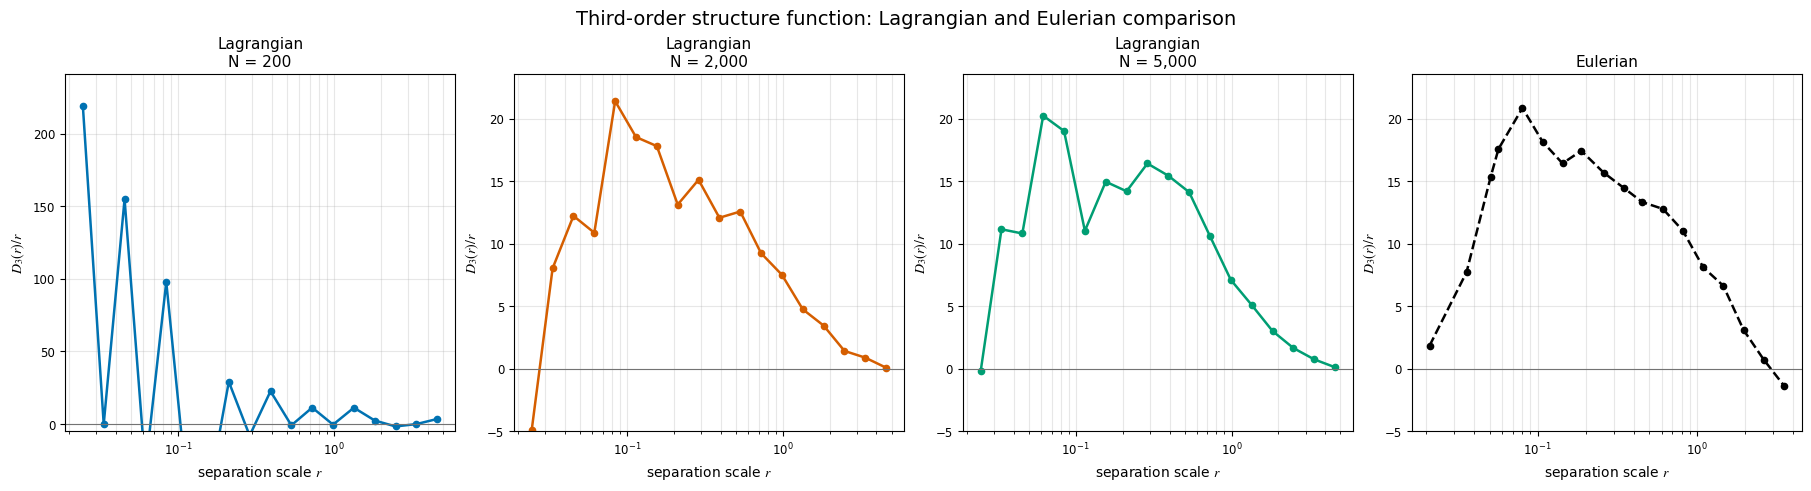

In [18]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. 需要已经在前面读取好的结果
# ============================================================

cases = [
    (
        result_200,
        "Lagrangian\nN = 200",
        "#0072B2",
        "-",
    ),
    (
        result_2000,
        "Lagrangian\nN = 2,000",
        "#D55E00",
        "-",
    ),
    (
        result_5000,
        "Lagrangian\nN = 5,000",
        "#009E73",
        "-",
    ),
    (
        result_eulerian,
        "Eulerian",
        "black",
        "--",
    ),
]


# ============================================================
# 2. 从 result 中读取一维数组
# ============================================================

def get_array(result, names):
    """
    按照 names 中的候选字段名读取数据。
    """
    for name in names:
        if name in result:
            value = np.asarray(result[name], dtype=float).squeeze()
            return np.ravel(value)

    raise KeyError(
        f"None of these fields were found: {names}\n"
        f"Available fields:\n{list(result.keys())}"
    )


def get_r(result):
    return get_array(
        result,
        [
            "dist_axis",
            "r_actual",
            "r_requested",
            "r",
            "separation",
        ],
    )


def get_D3(result):
    """
    兼容不同版本保存的第三阶结构函数字段。
    """

    # 直接保存的 D3
    for name in ["D3", "SF3", "mean_D3"]:
        if name in result:
            return get_array(result, [name])

    # 如果保存的是纵向和横向分量，则重构
    if "Dlll" in result and "Dltt" in result:
        return (
            get_array(result, ["Dlll"])
            + get_array(result, ["Dltt"])
        )

    if "SF3lll" in result and "SF3ltt" in result:
        return (
            get_array(result, ["SF3lll"])
            + get_array(result, ["SF3ltt"])
        )

    raise KeyError(
        "Cannot find a third-order structure-function field."
    )


# ============================================================
# 3. 准备每个 case 的 r、D3 和 D3/r
# ============================================================

plot_data = []

for result, label, color, linestyle in cases:

    r = get_r(result)
    D3 = get_D3(result)

    n = min(r.size, D3.size)

    r = r[:n]
    D3 = D3[:n]

    D3_over_r = np.divide(
        D3,
        r,
        out=np.full_like(D3, np.nan, dtype=float),
        where=np.isfinite(r) & (r > 0),
    )

    valid = (
        np.isfinite(r)
        & (r > 0)
        & np.isfinite(D3_over_r)
    )

    order = np.argsort(r[valid])

    plot_data.append(
        {
            "r": r[valid][order],
            "D3": D3[valid][order],
            "D3_over_r": D3_over_r[valid][order],
            "label": label,
            "color": color,
            "linestyle": linestyle,
        }
    )


# ============================================================
# 4. 计算前三个 Lagrangian case 的共同 y 轴范围
#
#    第一个图可以单独缩放；
#    后三个图使用同一个 ylim。
# ============================================================

all_values_for_common_ylim = []

for item in plot_data[1:]:
    values = item["D3_over_r"]

    values = values[
        np.isfinite(values)
    ]

    if values.size > 0:
        all_values_for_common_ylim.append(values)


if len(all_values_for_common_ylim) == 0:
    raise RuntimeError(
        "No valid D3/r values were found for common ylim."
    )


all_values_for_common_ylim = np.concatenate(
    all_values_for_common_ylim
)

common_abs = np.nanmax(
    np.abs(all_values_for_common_ylim)
)

if not np.isfinite(common_abs) or common_abs == 0:
    common_abs = 1.0

common_abs *= 1.10

common_ylim = (
    -5,
    common_abs,
)


# ============================================================
# 5. 第一幅图使用自己的范围
# ============================================================

first_values = plot_data[0]["D3_over_r"]

first_values = first_values[
    np.isfinite(first_values)
]

if first_values.size == 0:
    first_abs = common_abs
else:
    first_abs = np.nanmax(
        np.abs(first_values)
    )

if not np.isfinite(first_abs) or first_abs == 0:
    first_abs = common_abs

first_abs *= 1.10


# ============================================================
# 6. 画图
# ============================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=4,
    figsize=(18, 4.8),
    constrained_layout=True,
    sharex=False,
)


for i, item in enumerate(plot_data):

    ax = axes[i]

    r = item["r"]
    D3_over_r = item["D3_over_r"]

    # 不使用 "o-"，避免和 linestyle 重复定义
    ax.semilogx(
        r,
        D3_over_r,
        marker="o",
        markersize=4.5,
        color=item["color"],
        linestyle=item["linestyle"],
        linewidth=1.8,
        label=item["label"],
    )

    ax.axhline(
        0.0,
        color="0.45",
        linewidth=0.8,
    )

    ax.set_xlabel(
        "separation scale $r$"
    )

    ax.set_ylabel(
        r"$D_3(r)/r$"
    )

    ax.set_title(
        item["label"],
        fontsize=11,
    )

    ax.grid(
        True,
        which="both",
        alpha=0.3,
    )

    if i == 0:
        ax.set_ylim(
            -5,
            first_abs,
        )
    else:
        ax.set_ylim(
            common_ylim
        )
    # ax.set_ylim(common_ylim)


fig.suptitle(
    "Third-order structure function: "
    "Lagrangian and Eulerian comparison",
    fontsize=14,
)

output_png='/meddy/simingzhang/Data/SF_directly/SF3_hit.png'
fig.savefig(output_png,
    dpi=500,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

PDF scale indices: [0, 17]

PDF index = 0
Lagrangian
N = 200 r = 0.02454369260617026
Lagrangian
N = 2,000 r = 0.02454369260617026
Lagrangian
N = 5,000 r = 0.02454369260617026
Eulerian r = 0.020949352041675688

PDF index = 17
Lagrangian
N = 200 r = 4.6173070836605445
Lagrangian
N = 2,000 r = 4.6173070836605445
Lagrangian
N = 5,000 r = 4.6173070836605445
Eulerian r = 3.505712318390586


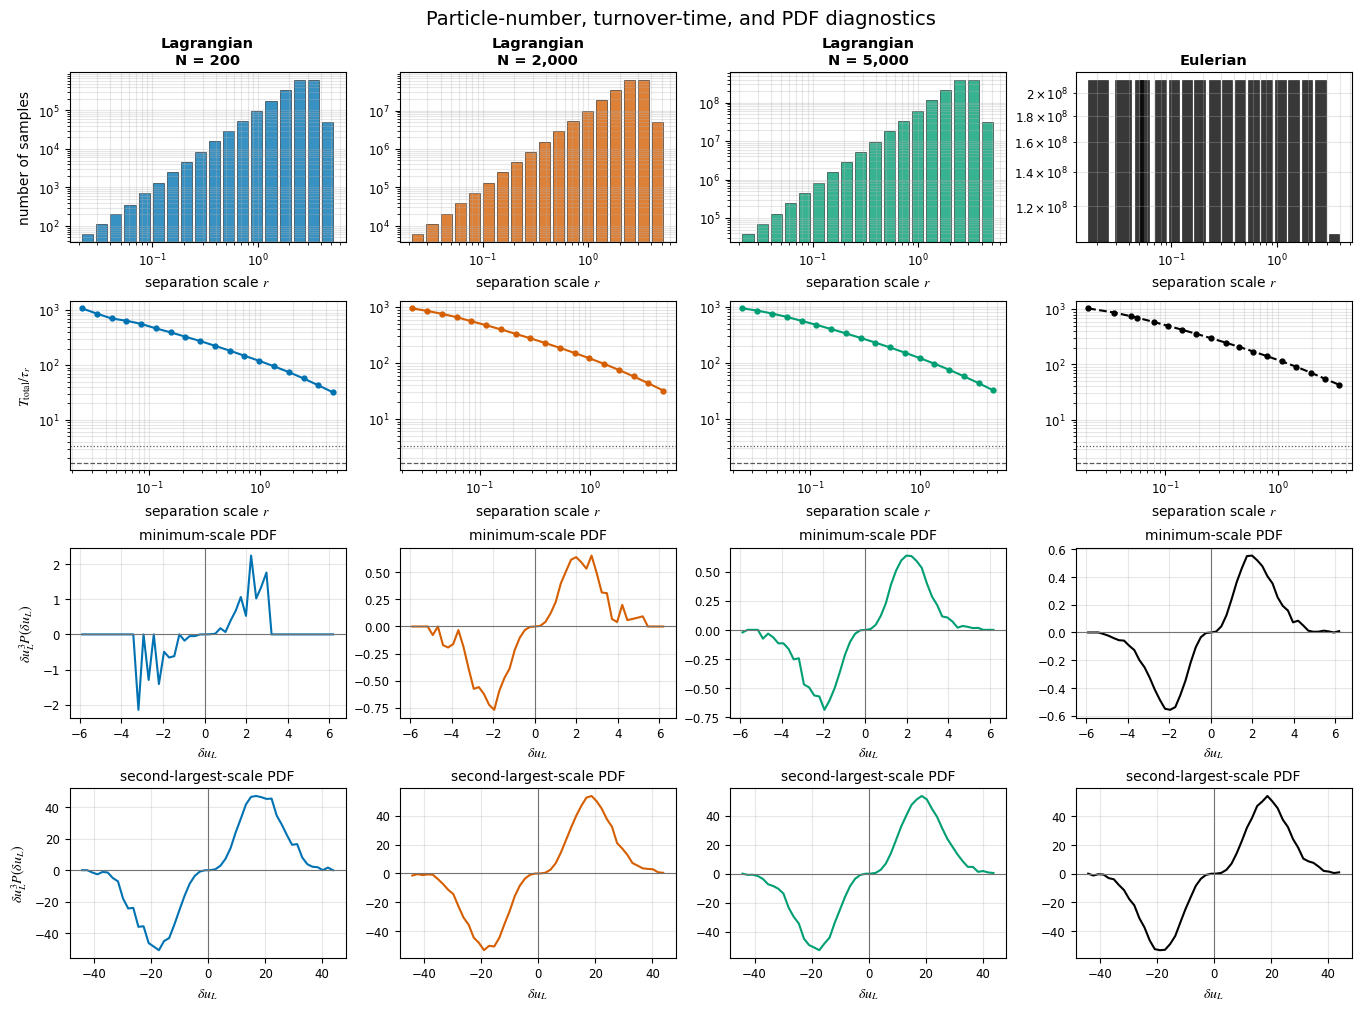

In [19]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. Cases
# ============================================================

cases = [
    (
        result_200,
        "Lagrangian\nN = 200",
        "#0072B2",
        "-",
        "lagrangian",
    ),
    (
        result_2000,
        "Lagrangian\nN = 2,000",
        "#D55E00",
        "-",
        "lagrangian",
    ),
    (
        result_5000,
        "Lagrangian\nN = 5,000",
        "#009E73",
        "-",
        "lagrangian",
    ),
    (
        result_eulerian,
        "Eulerian",
        "black",
        "--",
        "eulerian",
    ),
]


# ============================================================
# 2. Field readers
# ============================================================

def read_array(result, names, required=True):

    for name in names:

        if name in result:

            value = np.asarray(
                result[name],
                dtype=float,
            ).squeeze()

            return np.ravel(value)

    if required:
        raise KeyError(
            f"Cannot find fields {names}\n"
            f"Available fields:\n{list(result.keys())}"
        )

    return None


def read_r(result):

    return read_array(
        result,
        [
            "dist_axis",
            "r_actual",
            "r_requested",
            "r",
            "separation",
        ],
    )


def read_sf2(result):

    value = read_array(
        result,
        [
            "SF2",
            "sf2",
            "D2",
            "mean_D2",
        ],
        required=False,
    )

    if value is not None:
        return value

    dll = read_array(
        result,
        [
            "Dll",
            "D2ll",
            "SF2ll",
        ],
        required=False,
    )

    dtt = read_array(
        result,
        [
            "Dltt",
            "D2tt",
            "SF2tt",
        ],
        required=False,
    )

    if dll is not None and dtt is not None:
        return dll + dtt

    raise KeyError(
        "Cannot find SF2 or its components."
    )


def read_nsample(result, case_type):

    if case_type == "eulerian":

        sample_count = np.asarray(
            result["sample_count"],
            dtype=float,
        )

        if sample_count.ndim == 1:
            return sample_count

        # Eulerian sample_count shape: (nscale, nblock)
        return np.nansum(
            sample_count,
            axis=1,
        )

    for name in [
        "third_count",
        "dl_reservoir_count",
        "nsample",
        "n_samples",
        "sample_count",
        "pair_count",
    ]:

        if name in result:

            return np.asarray(
                result[name],
                dtype=float,
            ).ravel()

    return None


def read_reservoir(result):

    if "dl_reservoir" not in result:
        return None

    raw = np.asarray(
        result["dl_reservoir"],
        dtype=float,
    )

    if raw.ndim == 1:
        raw = raw[None, :]

    if "dl_reservoir_count" in result:

        count = np.asarray(
            result["dl_reservoir_count"],
            dtype=int,
        ).ravel()

    else:

        count = np.full(
            raw.shape[0],
            raw.shape[1],
            dtype=int,
        )

    output = []

    for i in range(raw.shape[0]):

        n = int(count[i])

        n = max(
            0,
            min(n, raw.shape[1]),
        )

        sample = raw[i, :n]

        sample = sample[
            np.isfinite(sample)
        ]

        output.append(sample)

    return output


# ============================================================
# 3. Build plotting data
# ============================================================

plot_data = []

for result, label, color, linestyle, case_type in cases:

    r = read_r(result)
    sf2 = read_sf2(result)
    nsample = read_nsample(
        result,
        case_type,
    )
    reservoir = read_reservoir(result)

    n = min(
        r.size,
        sf2.size,
    )

    if nsample is not None:
        n = min(
            n,
            nsample.size,
        )

    r = r[:n]
    sf2 = sf2[:n]

    if nsample is not None:
        nsample = nsample[:n]

    total_time = 10.0

    total_time_over_tau = np.divide(
        total_time * np.sqrt(
            np.maximum(sf2, 0.0)
        ),
        r,
        out=np.full(
            r.shape,
            np.nan,
            dtype=float,
        ),
        where=(
            np.isfinite(r)
            & (r > 0)
            & np.isfinite(sf2)
            & (sf2 > 0)
        ),
    )

    order = np.argsort(r)

    r = r[order]
    total_time_over_tau = total_time_over_tau[order]

    if nsample is not None:
        nsample = nsample[order]

    if reservoir is not None:

        sorted_reservoir = []

        for index in order:

            index = int(index)

            if index < len(reservoir):
                sorted_reservoir.append(
                    reservoir[index]
                )
            else:
                sorted_reservoir.append(
                    np.array([], dtype=float)
                )

        reservoir = sorted_reservoir

    plot_data.append(
        {
            "r": r,
            "nsample": nsample,
            "rate": total_time_over_tau,
            "reservoir": reservoir,
            "label": label,
            "color": color,
            "linestyle": linestyle,
        }
    )


# ============================================================
# 4. PDF scales
# ============================================================

common_nscale = min(
    item["r"].size
    for item in plot_data
)

pdf_indices = [
    0,
    common_nscale - 2,
]

print(
    "PDF scale indices:",
    pdf_indices,
)

for index in pdf_indices:

    print(
        f"\nPDF index = {index}"
    )

    for item in plot_data:

        print(
            item["label"],
            "r =",
            item["r"][index],
        )


# ============================================================
# 5. Build full-range PDF bins
# ============================================================

pdf_info = {}

for scale_index in pdf_indices:

    samples = []

    for item in plot_data:

        reservoir = item["reservoir"]

        if reservoir is None:
            continue

        if scale_index >= len(reservoir):
            continue

        sample = reservoir[scale_index]

        sample = sample[
            np.isfinite(sample)
        ]

        if sample.size > 0:
            samples.append(sample)

    if len(samples) == 0:

        pdf_info[scale_index] = None
        continue

    pooled = np.concatenate(samples)

    pdf_lo = np.nanmin(pooled)
    pdf_hi = np.nanmax(pooled)

    if pdf_lo == pdf_hi:

        width = max(
            1.0,
            abs(pdf_lo) * 0.1,
        )

        pdf_lo -= width
        pdf_hi += width

    bins = np.linspace(
        pdf_lo,
        pdf_hi,
        51,
    )

    centers = 0.5 * (
        bins[:-1]
        + bins[1:]
    )

    pdf_info[scale_index] = {
        "bins": bins,
        "centers": centers,
    }


# ============================================================
# 6. Plot: 4 rows × 4 columns
# ============================================================

fig, axes = plt.subplots(
    nrows=4,
    ncols=4,
    figsize=(13.5, 10.0),
    constrained_layout=True,
)


for col, item in enumerate(plot_data):

    r = item["r"]
    nsample = item["nsample"]
    rate = item["rate"]
    reservoir = item["reservoir"]

    color = item["color"]
    linestyle = item["linestyle"]
    label = item["label"]

    # --------------------------------------------------------
    # Row 1: sample count bars
    # --------------------------------------------------------

    ax = axes[0, col]

    if nsample is not None:

        valid = (
            np.isfinite(r)
            & (r > 0)
            & np.isfinite(nsample)
            & (nsample > 0)
        )

        rv = r[valid]
        nv = nsample[valid]

        if rv.size > 1:

            lr = np.log10(rv)

            edges_log = np.empty(
                rv.size + 1
            )

            edges_log[1:-1] = 0.5 * (
                lr[:-1] + lr[1:]
            )

            edges_log[0] = (
                lr[0]
                - 0.5 * (
                    lr[1] - lr[0]
                )
            )

            edges_log[-1] = (
                lr[-1]
                + 0.5 * (
                    lr[-1] - lr[-2]
                )
            )

            edges = 10.0**edges_log

            widths = 0.78 * (
                edges[1:] - edges[:-1]
            )

            ax.bar(
                rv,
                nv,
                width=widths,
                color=color,
                alpha=0.78,
                edgecolor="black",
                linewidth=0.45,
            )

            ax.set_xscale("log")
            ax.set_yscale("log")

    ax.set_title(
        label,
        fontsize=10.5,
        fontweight="bold",
    )

    ax.set_xlabel(
        "separation scale $r$"
    )

    if col == 0:
        ax.set_ylabel(
            "number of samples"
        )

    ax.grid(
        True,
        which="both",
        alpha=0.3,
    )

    # --------------------------------------------------------
    # Row 2: T_total / tau_r
    # --------------------------------------------------------

    ax = axes[1, col]

    valid = (
        np.isfinite(r)
        & (r > 0)
        & np.isfinite(rate)
        & (rate > 0)
    )

    if np.any(valid):

        ax.loglog(
            r[valid],
            rate[valid],
            marker="o",
            markersize=3.5,
            color=color,
            linestyle=linestyle,
            linewidth=1.5,
        )

    ax.axhline(
        10.0 / 3.0,
        color="0.35",
        linestyle=":",
        linewidth=0.9,
    )

    ax.axhline(
        10.0 / 6.0,
        color="0.35",
        linestyle="--",
        linewidth=0.9,
    )

    ax.set_xlabel(
        "separation scale $r$"
    )

    if col == 0:
        ax.set_ylabel(
            r"$T_{\rm total}/\tau_r$"
        )

    ax.grid(
        True,
        which="both",
        alpha=0.3,
    )

    # --------------------------------------------------------
    # Row 3 and Row 4: PDF at two scales
    # --------------------------------------------------------

    for row, scale_index in zip(
        [2, 3],
        pdf_indices,
    ):

        ax = axes[row, col]

        info = pdf_info[scale_index]

        if (
            reservoir is not None
            and scale_index < len(reservoir)
            and info is not None
        ):

            sample = reservoir[scale_index]

            sample = sample[
                np.isfinite(sample)
            ]

            if sample.size > 0:

                pdf, _ = np.histogram(
                    sample,
                    bins=info["bins"],
                    density=True,
                )

                contribution = (
                    info["centers"]**3 * pdf
                )

                ax.plot(
                    info["centers"],
                    contribution,
                    color=color,
                    linewidth=1.5,
                )

        else:

            ax.text(
                0.5,
                0.5,
                "No PDF reservoir",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=9,
            )

        ax.axhline(
            0.0,
            color="0.45",
            linewidth=0.8,
        )

        ax.axvline(
            0.0,
            color="0.45",
            linewidth=0.8,
        )

        ax.set_xlabel(
            r"$\delta u_L$"
        )

        if col == 0:
            ax.set_ylabel(
                r"$\delta u_L^3P(\delta u_L)$"
            )

        if row == 2:
            title = "minimum-scale PDF"
        else:
            title = "second-largest-scale PDF"

        ax.set_title(
            title,
            fontsize=10,
        )

        ax.grid(
            True,
            alpha=0.3,
        )


fig.suptitle(
    "Particle-number, turnover-time, and PDF diagnostics",
    fontsize=14,
)
output_png='/meddy/simingzhang/Data/SF_directly/recipe_hit.png'
fig.savefig(output_png,
    dpi=500,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()

Selected PDF indices: [0, 9, 16]
Reference scales used for displayed text: [0.02454369 0.39269908 3.39310774]
Lagrangian, $N=200$ actual selected scales: [0.02454369260617026, 0.39269908169872403, 3.393107741142179]
Lagrangian, $N=200$ displayed scale text: [0.02454369 0.39269908 3.39310774]
Lagrangian, $N=200$ nominal sampling scale: 0.44428829381583657
Lagrangian, $N=2{,}000$ actual selected scales: [0.02454369260617026, 0.39269908169872403, 3.393107741142179]
Lagrangian, $N=2{,}000$ displayed scale text: [0.02454369 0.39269908 3.39310774]
Lagrangian, $N=2{,}000$ nominal sampling scale: 0.1404962946208145
Lagrangian, $N=5{,}000$ actual selected scales: [0.02454369260617026, 0.39269908169872403, 3.393107741142179]
Lagrangian, $N=5{,}000$ displayed scale text: [0.02454369 0.39269908 3.39310774]
Lagrangian, $N=5{,}000$ nominal sampling scale: 0.08885765876316731
Eulerian actual selected scales: [0.020949352041675688, 0.345355963015003, 2.6172549978057407]
Eulerian displayed scale text: 

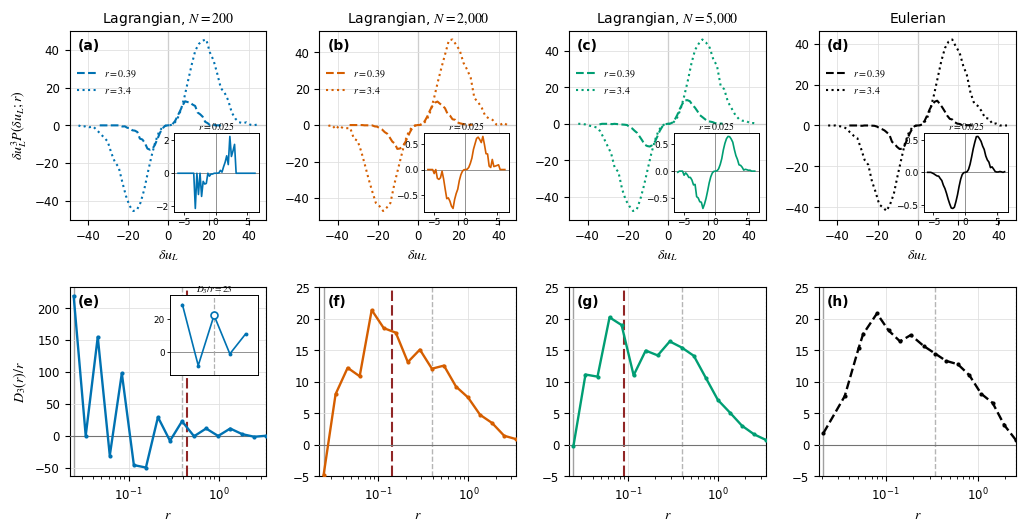

Saved: /meddy/simingzhang/Data/SF_directly/FigC_particle_number_PDF_SF3.png


In [29]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


# ============================================================
# 1. Global plotting style
# ============================================================

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "stix",
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "legend.fontsize": 7.2,
    "axes.linewidth": 0.8,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
})


# ============================================================
# 2. Cases
# ============================================================

cases = [
    {
        "result": result_200,
        "title": r"Lagrangian, $N=200$",
        "color": "#0072B2",
        "linestyle": "-",
        "particle_number": 200,
    },
    {
        "result": result_2000,
        "title": r"Lagrangian, $N=2{,}000$",
        "color": "#D55E00",
        "linestyle": "-",
        "particle_number": 2000,
    },
    {
        "result": result_5000,
        "title": r"Lagrangian, $N=5{,}000$",
        "color": "#009E73",
        "linestyle": "-",
        "particle_number": 5000,
    },
    {
        "result": result_eulerian,
        "title": "Eulerian",
        "color": "black",
        "linestyle": "--",
        "particle_number": None,
    },
]


# ============================================================
# 3. Field-reading functions
# ============================================================

def read_array(result, names, required=True):

    for name in names:

        if name in result:

            value = np.asarray(
                result[name],
                dtype=float,
            ).squeeze()

            return np.ravel(value)

    if required:

        raise KeyError(
            f"Cannot find any of the fields {names}.\n"
            f"Available fields:\n{list(result.keys())}"
        )

    return None


def read_r(result):

    return read_array(
        result,
        [
            "dist_axis",
            "r_actual",
            "r_requested",
            "r",
            "separation",
        ],
    )


def read_D3(result):

    value = read_array(
        result,
        [
            "D3",
            "SF3",
            "mean_D3",
        ],
        required=False,
    )

    if value is not None:
        return value

    if "Dlll" in result and "Dltt" in result:

        return (
            read_array(result, ["Dlll"])
            + read_array(result, ["Dltt"])
        )

    if "SF3lll" in result and "SF3ltt" in result:

        return (
            read_array(result, ["SF3lll"])
            + read_array(result, ["SF3ltt"])
        )

    raise KeyError(
        "Cannot find D3 or the longitudinal and transverse "
        "third-order components."
    )


def read_reservoir(result):

    if "dl_reservoir" not in result:
        return None

    raw = np.asarray(
        result["dl_reservoir"],
        dtype=float,
    )

    if raw.ndim == 1:
        raw = raw[None, :]

    if "dl_reservoir_count" in result:

        count = np.asarray(
            result["dl_reservoir_count"],
            dtype=int,
        ).ravel()

    else:

        count = np.full(
            raw.shape[0],
            raw.shape[1],
            dtype=int,
        )

    reservoir = []

    for i in range(raw.shape[0]):

        if i < count.size:
            nvalid = int(count[i])
        else:
            nvalid = raw.shape[1]

        nvalid = max(
            0,
            min(nvalid, raw.shape[1]),
        )

        sample = raw[i, :nvalid]

        sample = sample[
            np.isfinite(sample)
        ]

        reservoir.append(sample)

    return reservoir


# ============================================================
# 4. Prepare plotting data
# ============================================================

plot_data = []

for case in cases:

    result = case["result"]

    r = read_r(result)
    D3 = read_D3(result)
    reservoir = read_reservoir(result)

    nscale = min(
        r.size,
        D3.size,
    )

    if reservoir is not None:

        nscale = min(
            nscale,
            len(reservoir),
        )

    r = r[:nscale]
    D3 = D3[:nscale]

    if reservoir is not None:
        reservoir = reservoir[:nscale]

    D3_over_r = np.divide(
        D3,
        r,
        out=np.full(
            D3.shape,
            np.nan,
            dtype=float,
        ),
        where=(
            np.isfinite(r)
            & (r > 0)
            & np.isfinite(D3)
        ),
    )

    # Remove invalid separation values before sorting.
    finite_r = (
        np.isfinite(r)
        & (r > 0)
    )

    valid_original_indices = np.where(
        finite_r
    )[0]

    r = r[finite_r]
    D3 = D3[finite_r]
    D3_over_r = D3_over_r[finite_r]

    if reservoir is not None:

        reservoir = [
            reservoir[int(index)]
            for index in valid_original_indices
        ]

    order = np.argsort(r)

    r = r[order]
    D3 = D3[order]
    D3_over_r = D3_over_r[order]

    if reservoir is not None:

        reservoir = [
            reservoir[int(index)]
            for index in order
        ]

    particle_number = case["particle_number"]

    if particle_number is None:

        nominal_sampling_scale = None

    else:

        nominal_sampling_scale = (
            2.0
            * np.pi
            / np.sqrt(particle_number)
        )

    plot_data.append({
        "r": r,
        "D3": D3,
        "D3_over_r": D3_over_r,
        "reservoir": reservoir,
        "title": case["title"],
        "color": case["color"],
        "linestyle": case["linestyle"],
        "particle_number": particle_number,
        "nominal_sampling_scale": nominal_sampling_scale,
    })


# ============================================================
# 5. Select three scale indices
#
# Smallest scale
# Intermediate scale
# Second-largest scale
# ============================================================

common_nscale = min(
    item["r"].size
    for item in plot_data
)

if common_nscale < 4:

    raise RuntimeError(
        "At least four separation scales are required."
    )

pdf_indices = [
    0,
    common_nscale // 2,
    common_nscale - 2,
]

pdf_linestyles = [
    "-",
    "--",
    ":",
]

scale_marker_colors = [
    "0.56",
    "0.66",
    "0.76",
]

sampling_scale_color = "#8B1A1A"
sampling_scale_linestyle = (0, (5, 2))
sampling_scale_linewidth = 1.5


# ============================================================
# 6. Reference scales used only for displayed text
#
# All four columns use the N=200 Lagrangian r values in the
# legends and inset titles.
#
# Actual calculations, PDFs, curves, and vertical lines still
# use the actual r values of each individual case.
# ============================================================

text_reference_scales = np.asarray([
    plot_data[0]["r"][index]
    for index in pdf_indices
])


print(
    "Selected PDF indices:",
    pdf_indices,
)

print(
    "Reference scales used for displayed text:",
    text_reference_scales,
)


for item in plot_data:

    actual_scales = [
        item["r"][index]
        for index in pdf_indices
    ]

    print(
        item["title"],
        "actual selected scales:",
        actual_scales,
    )

    print(
        item["title"],
        "displayed scale text:",
        text_reference_scales,
    )

    if item["nominal_sampling_scale"] is not None:

        print(
            item["title"],
            "nominal sampling scale:",
            item["nominal_sampling_scale"],
        )


# ============================================================
# 7. Build common PDF bins at each selected index
#
# At a given selected index, all four cases use the same bins.
# The samples themselves remain case-specific.
# ============================================================

NBINS = 50

pdf_info = {}

for scale_index in pdf_indices:

    samples_at_this_scale = []

    for item in plot_data:

        reservoir = item["reservoir"]

        if reservoir is None:
            continue

        if scale_index >= len(reservoir):
            continue

        sample = np.asarray(
            reservoir[scale_index],
            dtype=float,
        )

        sample = sample[
            np.isfinite(sample)
        ]

        if sample.size > 0:
            samples_at_this_scale.append(sample)

    if len(samples_at_this_scale) == 0:

        pdf_info[scale_index] = None
        continue

    pooled = np.concatenate(
        samples_at_this_scale
    )

    pdf_min = np.nanmin(pooled)
    pdf_max = np.nanmax(pooled)

    if (
        not np.isfinite(pdf_min)
        or not np.isfinite(pdf_max)
    ):

        pdf_info[scale_index] = None
        continue

    if pdf_min == pdf_max:

        half_width = max(
            1.0,
            0.1 * abs(pdf_min),
        )

        pdf_min -= half_width
        pdf_max += half_width

    bins = np.linspace(
        pdf_min,
        pdf_max,
        NBINS + 1,
    )

    centers = 0.5 * (
        bins[:-1]
        + bins[1:]
    )

    pdf_info[scale_index] = {
        "bins": bins,
        "centers": centers,
    }


# ============================================================
# 8. Create figure
# ============================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=4,
    figsize=(10.4, 5.6),
    sharex=False,
    constrained_layout=False,
)

fig.subplots_adjust(
    left=0.075,
    right=0.985,
    bottom=0.115,
    top=0.91,
    wspace=0.27,
    hspace=0.36,
)

panel_labels = [
    "(a)", "(b)", "(c)", "(d)",
    "(e)", "(f)", "(g)", "(h)",
]

pdf_inset_axes = []


# ============================================================
# 9. First row
#
# Main panels:
# intermediate- and second-largest-scale weighted PDFs
#
# Insets:
# smallest-scale weighted PDF
# ============================================================

for col, item in enumerate(plot_data):

    ax = axes[0, col]

    reservoir = item["reservoir"]

    minimum_scale_x = None
    minimum_scale_y = None
    minimum_scale_text_r = None

    for curve_number, (
        scale_index,
        linestyle,
    ) in enumerate(
        zip(
            pdf_indices,
            pdf_linestyles,
        )
    ):

        info = pdf_info[scale_index]

        if (
            reservoir is None
            or info is None
            or scale_index >= len(reservoir)
        ):
            continue

        sample = np.asarray(
            reservoir[scale_index],
            dtype=float,
        )

        sample = sample[
            np.isfinite(sample)
        ]

        if sample.size == 0:
            continue

        pdf, _ = np.histogram(
            sample,
            bins=info["bins"],
            density=True,
        )

        contribution = (
            info["centers"]**3
            * pdf
        )

        # Actual scale used for this case.
        actual_scale_value = (
            item["r"][scale_index]
        )

        # Scale used only in the displayed text.
        displayed_scale_value = (
            text_reference_scales[curve_number]
        )

        print(
            item["title"],
            "actual r =",
            actual_scale_value,
            "displayed r =",
            displayed_scale_value,
        )

        # Smallest scale: inset only.
        if curve_number == 0:

            minimum_scale_x = (
                info["centers"].copy()
            )

            minimum_scale_y = (
                contribution.copy()
            )

            minimum_scale_text_r = (
                displayed_scale_value
            )

            continue

        # Plot actual case-specific PDF.
        # Display the common N=200 reference-scale text.
        ax.plot(
            info["centers"],
            contribution,
            color=item["color"],
            linestyle=linestyle,
            linewidth=1.5,
            label=(
                rf"$r="
                rf"{displayed_scale_value:.2g}$"
            ),
        )

    ax.axhline(
        0.0,
        color="0.45",
        linewidth=0.8,
        zorder=0,
    )

    ax.axvline(
        0.0,
        color="0.45",
        linewidth=0.8,
        zorder=0,
    )

    ax.set_title(
        item["title"],
        fontweight="normal",
        pad=6,
    )

    ax.set_xlabel(
        r"$\delta u_L$"
    )

    if col == 0:

        ax.set_ylabel(
            r"$\delta u_L^3P(\delta u_L;r)$"
        )

    ax.grid(
        True,
        which="major",
        color="0.88",
        linewidth=0.6,
    )

    ax.tick_params(
        axis="both",
        which="both",
        direction="out",
    )

    ax.text(
        0.04,
        0.96,
        panel_labels[col],
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        fontweight="bold",
    )

    ax.legend(
        loc="upper left",
        bbox_to_anchor=(0.0, 0.84),
        frameon=False,
        handlelength=2.2,
        handletextpad=0.5,
        borderaxespad=0.3,
    )

    # --------------------------------------------------------
    # Inset: smallest-scale weighted PDF
    # --------------------------------------------------------

    if (
        minimum_scale_x is not None
        and minimum_scale_y is not None
    ):

        axins = inset_axes(
            ax,
            width="43%",
            height="42%",
            loc="lower right",
            borderpad=0.75,
        )

        axins.plot(
            minimum_scale_x,
            minimum_scale_y,
            color=item["color"],
            linestyle=pdf_linestyles[0],
            linewidth=1.2,
        )

        axins.axhline(
            0.0,
            color="0.5",
            linewidth=0.6,
            zorder=0,
        )

        axins.axvline(
            0.0,
            color="0.5",
            linewidth=0.6,
            zorder=0,
        )

        # All four inset titles display the same N=200
        # Lagrangian reference-scale value.
        axins.set_title(
            rf"$r={minimum_scale_text_r:.2g}$",
            fontsize=7,
            pad=2,
        )

        axins.tick_params(
            axis="both",
            which="major",
            labelsize=6.5,
            direction="out",
            length=2.5,
            width=0.6,
            pad=1.5,
        )

        axins.grid(False)

        for spine in axins.spines.values():
            spine.set_linewidth(0.7)

        pdf_inset_axes.append(axins)

    else:

        pdf_inset_axes.append(None)


# ============================================================
# 10. Second row: D3(r)/r
#
# Curves and scale markers use each case's actual r values.
# The maximum available scale is excluded.
# ============================================================

for col, item in enumerate(plot_data):

    ax = axes[1, col]

    r = item["r"]
    D3_over_r = item["D3_over_r"]

    # Use the actual second-largest selected scale for this case.
    maximum_plot_index = pdf_indices[-1]
    maximum_plot_scale = r[maximum_plot_index]

    if (
        not np.isfinite(maximum_plot_scale)
        or maximum_plot_scale <= 0
    ):

        raise ValueError(
            f"Invalid maximum scale for "
            f"{item['title']}: "
            f"{maximum_plot_scale}"
        )

    valid = (
        np.isfinite(r)
        & (r > 0)
        & (r <= maximum_plot_scale)
        & np.isfinite(D3_over_r)
    )

    if not np.any(valid):

        raise ValueError(
            f"No valid D3/r data for "
            f"{item['title']}."
        )

    # Three actual scale positions used for the PDFs.
    for (
        scale_index,
        scale_linestyle,
        scale_color,
    ) in zip(
        pdf_indices,
        pdf_linestyles,
        scale_marker_colors,
    ):

        scale_value = r[scale_index]

        if (
            not np.isfinite(scale_value)
            or scale_value <= 0
            or scale_value > maximum_plot_scale
        ):
            continue

        ax.axvline(
            scale_value,
            color=scale_color,
            linestyle=scale_linestyle,
            linewidth=1.0,
            alpha=0.85,
            zorder=1,
        )

    # Nominal particle spacing:
    # Lagrangian panels only.
    if item["nominal_sampling_scale"] is not None:

        nominal_scale = (
            item["nominal_sampling_scale"]
        )

        if (
            np.isfinite(nominal_scale)
            and nominal_scale > 0
        ):

            ax.axvline(
                nominal_scale,
                color=sampling_scale_color,
                linestyle=sampling_scale_linestyle,
                linewidth=sampling_scale_linewidth,
                alpha=0.95,
                zorder=2,
            )

    ax.semilogx(
        r[valid],
        D3_over_r[valid],
        color=item["color"],
        linestyle=item["linestyle"],
        linewidth=1.7,
        marker="o",
        markersize=3.0,
        markerfacecolor=item["color"],
        markeredgewidth=0,
        zorder=4,
    )

    ax.axhline(
        0.0,
        color="0.45",
        linewidth=0.8,
        zorder=3,
    )

    ax.set_xlabel(
        r"$r$"
    )

    if col == 0:

        ax.set_ylabel(
            r"$D_3(r)/r$"
        )

    ax.grid(
        True,
        which="major",
        color="0.88",
        linewidth=0.6,
        zorder=0,
    )

    ax.grid(
        False,
        which="minor",
    )

    ax.tick_params(
        axis="both",
        which="both",
        direction="out",
    )

    ax.text(
        0.04,
        0.96,
        panel_labels[4 + col],
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        fontweight="bold",
    )

    minimum_plot_scale = np.nanmin(
        r[valid]
    )

    if item["nominal_sampling_scale"] is not None:

        nominal_scale = (
            item["nominal_sampling_scale"]
        )

        if (
            np.isfinite(nominal_scale)
            and nominal_scale > 0
        ):

            minimum_plot_scale = min(
                minimum_plot_scale,
                nominal_scale,
            )

    ax.set_xlim(
        0.90 * minimum_plot_scale,
        maximum_plot_scale,
    )


# ============================================================
# 11. Axis limits
# ============================================================

axes[1, 1].set_ylim(-5, 25)
axes[1, 2].set_ylim(-5, 25)
axes[1, 3].set_ylim(-5, 25)


# ============================================================
# 12. Inset in panel (e)
#
# Zoom around the intermediate selected scale for N=200.
# ============================================================

ax_bottom_first = axes[1, 0]

item_first = plot_data[0]

r_first = item_first["r"]
D3_over_r_first = item_first["D3_over_r"]

middle_index = pdf_indices[1]

middle_r = r_first[middle_index]
middle_D3_over_r = D3_over_r_first[middle_index]

print(
    "N=200 intermediate-scale value:"
)

print(
    f"r = {middle_r:.8g}, "
    f"D3(r)/r = {middle_D3_over_r:.8g}"
)


zoom_start = max(
    0,
    middle_index - 2,
)

zoom_end = min(
    r_first.size - 1,
    middle_index + 3,
)

zoom_r = r_first[
    zoom_start:zoom_end
]

zoom_D3_over_r = D3_over_r_first[
    zoom_start:zoom_end
]

zoom_valid = (
    np.isfinite(zoom_r)
    & (zoom_r > 0)
    & np.isfinite(zoom_D3_over_r)
)

zoom_r = zoom_r[zoom_valid]
zoom_D3_over_r = zoom_D3_over_r[zoom_valid]


axins_middle = inset_axes(
    ax_bottom_first,
    width="45%",
    height="42%",
    loc="upper right",
    borderpad=0.8,
)


axins_middle.semilogx(
    zoom_r,
    zoom_D3_over_r,
    color=item_first["color"],
    linestyle=item_first["linestyle"],
    linewidth=1.2,
    marker="o",
    markersize=2.8,
    markerfacecolor=item_first["color"],
    markeredgewidth=0,
)


axins_middle.plot(
    middle_r,
    middle_D3_over_r,
    marker="o",
    markersize=5.0,
    markerfacecolor="white",
    markeredgecolor=item_first["color"],
    markeredgewidth=1.2,
    linestyle="none",
    zorder=5,
)


axins_middle.axvline(
    middle_r,
    color=scale_marker_colors[1],
    linestyle=pdf_linestyles[1],
    linewidth=0.9,
    alpha=0.9,
    zorder=1,
)


axins_middle.axhline(
    0.0,
    color="0.5",
    linewidth=0.6,
    zorder=0,
)


# Automatic local x limits.
if zoom_r.size >= 2:

    log_zoom_r = np.log10(
        zoom_r
    )

    log_width = (
        log_zoom_r[-1]
        - log_zoom_r[0]
    )

    left_log = (
        log_zoom_r[0]
        - 0.20 * log_width
    )

    right_log = (
        log_zoom_r[-1]
        + 0.20 * log_width
    )

    axins_middle.set_xlim(
        10.0**left_log,
        10.0**right_log,
    )


# Automatic local y limits.
if zoom_D3_over_r.size > 0:

    zoom_ymin = np.nanmin(
        zoom_D3_over_r
    )

    zoom_ymax = np.nanmax(
        zoom_D3_over_r
    )

    zoom_yrange = (
        zoom_ymax
        - zoom_ymin
    )

    if (
        not np.isfinite(zoom_yrange)
        or zoom_yrange == 0
    ):

        zoom_yrange = max(
            abs(zoom_ymin),
            abs(zoom_ymax),
            1.0,
        )

    axins_middle.set_ylim(
        zoom_ymin - 0.15 * zoom_yrange,
        zoom_ymax + 0.15 * zoom_yrange,
    )


axins_middle.set_title(
    rf"$D_3/r={middle_D3_over_r:.2g}$",
    fontsize=6.8,
    pad=2,
)


axins_middle.tick_params(
    axis="y",
    which="major",
    labelsize=6.3,
    direction="out",
    length=2.4,
    width=0.6,
    pad=1.2,
)


# No x-axis ticks or numbers.
axins_middle.tick_params(
    axis="x",
    which="both",
    bottom=False,
    top=False,
    labelbottom=False,
)


axins_middle.grid(False)

for spine in axins_middle.spines.values():
    spine.set_linewidth(0.7)


# ============================================================
# 13. Optional manual adjustments
# ============================================================

# First-row panels:
# axes[0, 0].set_xlim(-2, 2)
# axes[0, 0].set_ylim(-5, 5)

# First D3/r panel:
# axes[1, 0].set_ylim(-5, 100)

# Small-scale PDF insets:
# if pdf_inset_axes[0] is not None:
#     pdf_inset_axes[0].set_xlim(-0.5, 0.5)
#     pdf_inset_axes[0].set_ylim(-0.1, 0.1)

# Panel (e) inset:
# axins_middle.set_ylim(-5, 25)


# ============================================================
# 14. Save
# ============================================================

output_png = (
    "/meddy/simingzhang/Data/SF_directly/"
    "FigC_particle_number_PDF_SF3.png"
)

fig.savefig(
    output_png,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print(f"Saved: {output_png}")

Selected PDF indices: [0, 9, 16]
Reference scales used for displayed text: [0.02454369 0.39269908 3.39310774]
Lagrangian, $N=200$ actual selected scales: [0.02454369260617026, 0.39269908169872403, 3.393107741142179]
Lagrangian, $N=200$ mean particle spacing = 0.44428829381583657
Lagrangian, $N=200$ nominal Nyquist-like scale = 0.8885765876316731
Lagrangian, $N=2{,}000$ actual selected scales: [0.02454369260617026, 0.39269908169872403, 3.393107741142179]
Lagrangian, $N=2{,}000$ mean particle spacing = 0.1404962946208145
Lagrangian, $N=2{,}000$ nominal Nyquist-like scale = 0.280992589241629
Lagrangian, $N=5{,}000$ actual selected scales: [0.02454369260617026, 0.39269908169872403, 3.393107741142179]
Lagrangian, $N=5{,}000$ mean particle spacing = 0.08885765876316731
Lagrangian, $N=5{,}000$ nominal Nyquist-like scale = 0.17771531752633463
Eulerian actual selected scales: [0.020949352041675688, 0.345355963015003, 2.6172549978057407]
N=200 effective sampling scale = 0.8885765876316731
Select

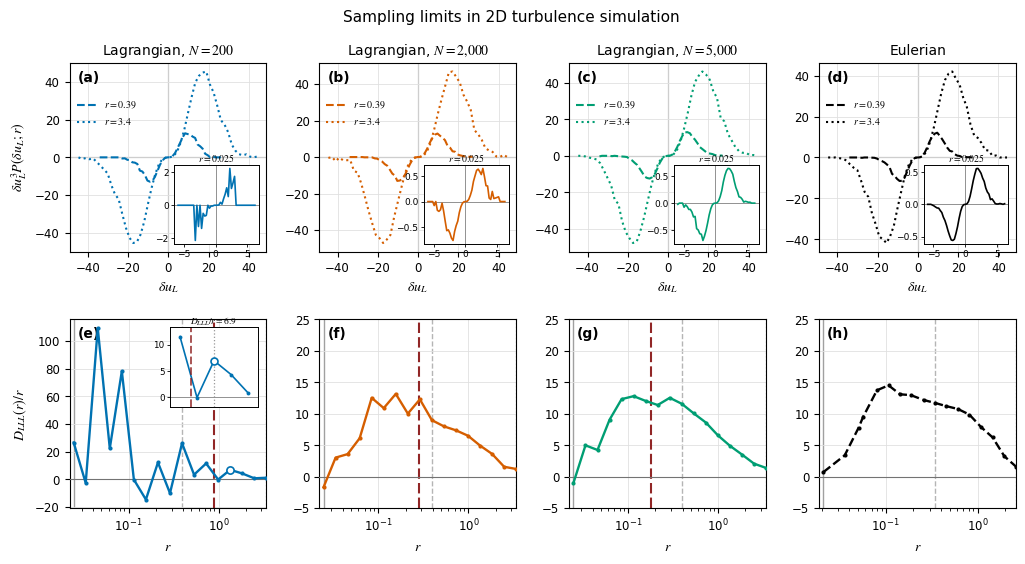

Saved: /meddy/simingzhang/Data/SF_directly/FigC_particle_number_PDF_Dlll_effective_resolution.png


In [39]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


# ============================================================
# 1. Global plotting style
# ============================================================

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "stix",
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "legend.fontsize": 7.2,
    "axes.linewidth": 0.8,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
})


# ============================================================
# 2. Cases
# ============================================================

cases = [
    {
        "result": result_200,
        "title": r"Lagrangian, $N=200$",
        "color": "#0072B2",
        "linestyle": "-",
        "particle_number": 200,
    },
    {
        "result": result_2000,
        "title": r"Lagrangian, $N=2{,}000$",
        "color": "#D55E00",
        "linestyle": "-",
        "particle_number": 2000,
    },
    {
        "result": result_5000,
        "title": r"Lagrangian, $N=5{,}000$",
        "color": "#009E73",
        "linestyle": "-",
        "particle_number": 5000,
    },
    {
        "result": result_eulerian,
        "title": "Eulerian",
        "color": "black",
        "linestyle": "--",
        "particle_number": None,
    },
]


# ============================================================
# 3. Field-reading functions
# ============================================================

def read_array(result, names, required=True):

    for name in names:

        if name in result:

            value = np.asarray(
                result[name],
                dtype=float,
            ).squeeze()

            return np.ravel(value)

    if required:

        raise KeyError(
            f"Cannot find any of the fields {names}.\n"
            f"Available fields:\n{list(result.keys())}"
        )

    return None


def read_r(result):

    return read_array(
        result,
        [
            "dist_axis",
            "r_actual",
            "r_requested",
            "r",
            "separation",
        ],
    )


def read_Dlll(result):

    return read_array(
        result,
        [
            "Dlll",
            "mean_Dlll",
            "SF3lll",
        ],
        required=True,
    )


def read_reservoir(result):

    if "dl_reservoir" not in result:
        return None

    raw = np.asarray(
        result["dl_reservoir"],
        dtype=float,
    )

    if raw.ndim == 1:
        raw = raw[None, :]

    if "dl_reservoir_count" in result:

        count = np.asarray(
            result["dl_reservoir_count"],
            dtype=int,
        ).ravel()

    else:

        count = np.full(
            raw.shape[0],
            raw.shape[1],
            dtype=int,
        )

    reservoir = []

    for i in range(raw.shape[0]):

        if i < count.size:
            nvalid = int(count[i])
        else:
            nvalid = raw.shape[1]

        nvalid = max(
            0,
            min(nvalid, raw.shape[1]),
        )

        sample = raw[i, :nvalid]

        sample = sample[
            np.isfinite(sample)
        ]

        reservoir.append(sample)

    return reservoir


# ============================================================
# 4. Prepare plotting data
# ============================================================

plot_data = []

for case in cases:

    result = case["result"]

    r = read_r(result)
    Dlll = read_Dlll(result)
    reservoir = read_reservoir(result)

    nscale = min(
        r.size,
        Dlll.size,
    )

    if reservoir is not None:

        nscale = min(
            nscale,
            len(reservoir),
        )

    r = r[:nscale]
    Dlll = Dlll[:nscale]

    if reservoir is not None:
        reservoir = reservoir[:nscale]

    Dlll_over_r = np.divide(
        Dlll,
        r,
        out=np.full(
            Dlll.shape,
            np.nan,
            dtype=float,
        ),
        where=(
            np.isfinite(r)
            & (r > 0)
            & np.isfinite(Dlll)
        ),
    )

    finite_r = (
        np.isfinite(r)
        & (r > 0)
    )

    valid_original_indices = np.where(
        finite_r
    )[0]

    r = r[finite_r]
    Dlll = Dlll[finite_r]
    Dlll_over_r = Dlll_over_r[finite_r]

    if reservoir is not None:

        reservoir = [
            reservoir[int(index)]
            for index in valid_original_indices
        ]

    order = np.argsort(r)

    r = r[order]
    Dlll = Dlll[order]
    Dlll_over_r = Dlll_over_r[order]

    if reservoir is not None:

        reservoir = [
            reservoir[int(index)]
            for index in order
        ]

    particle_number = case["particle_number"]

    if particle_number is None:

        mean_particle_spacing = None
        effective_sampling_scale = None

    else:

        mean_particle_spacing = (
            2.0
            * np.pi
            / np.sqrt(particle_number)
        )

        effective_sampling_scale = (
            2.0
            * mean_particle_spacing
        )

    plot_data.append({
        "r": r,
        "Dlll": Dlll,
        "Dlll_over_r": Dlll_over_r,
        "reservoir": reservoir,
        "title": case["title"],
        "color": case["color"],
        "linestyle": case["linestyle"],
        "particle_number": particle_number,
        "mean_particle_spacing": mean_particle_spacing,
        "effective_sampling_scale": effective_sampling_scale,
    })


# ============================================================
# 5. Select three scale indices
# ============================================================

common_nscale = min(
    item["r"].size
    for item in plot_data
)

if common_nscale < 4:

    raise RuntimeError(
        "At least four separation scales are required."
    )

pdf_indices = [
    0,
    common_nscale // 2,
    common_nscale - 2,
]

pdf_linestyles = [
    "-",
    "--",
    ":",
]

scale_marker_colors = [
    "0.56",
    "0.66",
    "0.76",
]

effective_scale_color = "#8B1A1A"
effective_scale_linestyle = (0, (5, 2))
effective_scale_linewidth = 1.5


# ============================================================
# 6. Reference scales used only for displayed text
# ============================================================

text_reference_scales = np.asarray([
    plot_data[0]["r"][index]
    for index in pdf_indices
])


print(
    "Selected PDF indices:",
    pdf_indices,
)

print(
    "Reference scales used for displayed text:",
    text_reference_scales,
)


for item in plot_data:

    actual_scales = [
        item["r"][index]
        for index in pdf_indices
    ]

    print(
        item["title"],
        "actual selected scales:",
        actual_scales,
    )

    if item["particle_number"] is not None:

        print(
            item["title"],
            "mean particle spacing =",
            item["mean_particle_spacing"],
        )

        print(
            item["title"],
            "nominal Nyquist-like scale =",
            item["effective_sampling_scale"],
        )


# ============================================================
# 7. Build common PDF bins at each selected index
# ============================================================

NBINS = 50

pdf_info = {}

for scale_index in pdf_indices:

    samples_at_this_scale = []

    for item in plot_data:

        reservoir = item["reservoir"]

        if reservoir is None:
            continue

        if scale_index >= len(reservoir):
            continue

        sample = np.asarray(
            reservoir[scale_index],
            dtype=float,
        )

        sample = sample[
            np.isfinite(sample)
        ]

        if sample.size > 0:
            samples_at_this_scale.append(sample)

    if len(samples_at_this_scale) == 0:

        pdf_info[scale_index] = None
        continue

    pooled = np.concatenate(
        samples_at_this_scale
    )

    pdf_min = np.nanmin(pooled)
    pdf_max = np.nanmax(pooled)

    if (
        not np.isfinite(pdf_min)
        or not np.isfinite(pdf_max)
    ):

        pdf_info[scale_index] = None
        continue

    if pdf_min == pdf_max:

        half_width = max(
            1.0,
            0.1 * abs(pdf_min),
        )

        pdf_min -= half_width
        pdf_max += half_width

    bins = np.linspace(
        pdf_min,
        pdf_max,
        NBINS + 1,
    )

    centers = 0.5 * (
        bins[:-1]
        + bins[1:]
    )

    pdf_info[scale_index] = {
        "bins": bins,
        "centers": centers,
    }


# ============================================================
# 8. Create figure
# ============================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=4,
    figsize=(10.4, 5.6),
    sharex=False,
    constrained_layout=False,
)

fig.subplots_adjust(
    left=0.075,
    right=0.985,
    bottom=0.115,
    top=0.91,
    wspace=0.27,
    hspace=0.36,
)

panel_labels = [
    "(a)", "(b)", "(c)", "(d)",
    "(e)", "(f)", "(g)", "(h)",
]

pdf_inset_axes = []


# ============================================================
# 9. First row
# ============================================================

for col, item in enumerate(plot_data):

    ax = axes[0, col]

    reservoir = item["reservoir"]

    minimum_scale_x = None
    minimum_scale_y = None
    minimum_scale_text_r = None

    for curve_number, (
        scale_index,
        linestyle,
    ) in enumerate(
        zip(
            pdf_indices,
            pdf_linestyles,
        )
    ):

        info = pdf_info[scale_index]

        if (
            reservoir is None
            or info is None
            or scale_index >= len(reservoir)
        ):
            continue

        sample = np.asarray(
            reservoir[scale_index],
            dtype=float,
        )

        sample = sample[
            np.isfinite(sample)
        ]

        if sample.size == 0:
            continue

        pdf, _ = np.histogram(
            sample,
            bins=info["bins"],
            density=True,
        )

        contribution = (
            info["centers"]**3
            * pdf
        )

        displayed_scale_value = (
            text_reference_scales[curve_number]
        )

        # Smallest scale: inset only.
        if curve_number == 0:

            minimum_scale_x = (
                info["centers"].copy()
            )

            minimum_scale_y = (
                contribution.copy()
            )

            minimum_scale_text_r = (
                displayed_scale_value
            )

            continue

        ax.plot(
            info["centers"],
            contribution,
            color=item["color"],
            linestyle=linestyle,
            linewidth=1.5,
            label=(
                rf"$r="
                rf"{displayed_scale_value:.2g}$"
            ),
        )

    ax.axhline(
        0.0,
        color="0.45",
        linewidth=0.8,
        zorder=0,
    )

    ax.axvline(
        0.0,
        color="0.45",
        linewidth=0.8,
        zorder=0,
    )

    ax.set_title(
        item["title"],
        fontweight="normal",
        pad=6,
    )

    ax.set_xlabel(
        r"$\delta u_L$"
    )

    if col == 0:

        ax.set_ylabel(
            r"$\delta u_L^3P(\delta u_L;r)$"
        )

    ax.grid(
        True,
        which="major",
        color="0.88",
        linewidth=0.6,
    )

    ax.tick_params(
        axis="both",
        which="both",
        direction="out",
    )

    ax.text(
        0.04,
        0.96,
        panel_labels[col],
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        fontweight="bold",
    )

    ax.legend(
        loc="upper left",
        bbox_to_anchor=(0.0, 0.84),
        frameon=False,
        handlelength=2.2,
        handletextpad=0.5,
        borderaxespad=0.3,
    )

    # --------------------------------------------------------
    # Inset: smallest-scale weighted PDF
    # --------------------------------------------------------

    if (
        minimum_scale_x is not None
        and minimum_scale_y is not None
    ):

        axins = inset_axes(
            ax,
            width="43%",
            height="42%",
            loc="lower right",
            borderpad=0.75,
        )

        axins.plot(
            minimum_scale_x,
            minimum_scale_y,
            color=item["color"],
            linestyle=pdf_linestyles[0],
            linewidth=1.2,
        )

        axins.axhline(
            0.0,
            color="0.5",
            linewidth=0.6,
            zorder=0,
        )

        axins.axvline(
            0.0,
            color="0.5",
            linewidth=0.6,
            zorder=0,
        )

        axins.set_title(
            rf"$r={minimum_scale_text_r:.2g}$",
            fontsize=7,
            pad=2,
        )

        axins.tick_params(
            axis="both",
            which="major",
            labelsize=6.5,
            direction="out",
            length=2.5,
            width=0.6,
            pad=1.5,
        )

        axins.grid(False)

        for spine in axins.spines.values():
            spine.set_linewidth(0.7)

        pdf_inset_axes.append(axins)

    else:

        pdf_inset_axes.append(None)


# ============================================================
# 10. Second row: D_LLL(r)/r
# ============================================================

for col, item in enumerate(plot_data):

    ax = axes[1, col]

    r = item["r"]
    Dlll_over_r = item["Dlll_over_r"]

    maximum_plot_index = pdf_indices[-1]
    maximum_plot_scale = r[maximum_plot_index]

    valid = (
        np.isfinite(r)
        & (r > 0)
        & (r <= maximum_plot_scale)
        & np.isfinite(Dlll_over_r)
    )

    if not np.any(valid):

        raise ValueError(
            f"No valid D_LLL/r data for "
            f"{item['title']}."
        )

    for (
        scale_index,
        scale_linestyle,
        scale_color,
    ) in zip(
        pdf_indices,
        pdf_linestyles,
        scale_marker_colors,
    ):

        scale_value = r[scale_index]

        if (
            not np.isfinite(scale_value)
            or scale_value <= 0
            or scale_value > maximum_plot_scale
        ):
            continue

        ax.axvline(
            scale_value,
            color=scale_color,
            linestyle=scale_linestyle,
            linewidth=1.0,
            alpha=0.85,
            zorder=1,
        )

    # Nominal Nyquist-like scale:
    # r_N = 4*pi/sqrt(N)
    if item["effective_sampling_scale"] is not None:

        effective_scale = (
            item["effective_sampling_scale"]
        )

        ax.axvline(
            effective_scale,
            color=effective_scale_color,
            linestyle=effective_scale_linestyle,
            linewidth=effective_scale_linewidth,
            alpha=0.95,
            zorder=2,
        )

    ax.semilogx(
        r[valid],
        Dlll_over_r[valid],
        color=item["color"],
        linestyle=item["linestyle"],
        linewidth=1.7,
        marker="o",
        markersize=3.0,
        markerfacecolor=item["color"],
        markeredgewidth=0,
        zorder=4,
    )

    ax.axhline(
        0.0,
        color="0.45",
        linewidth=0.8,
        zorder=3,
    )

    ax.set_xlabel(
        r"$r$"
    )

    if col == 0:

        ax.set_ylabel(
            r"$D_{LLL}(r)/r$"
        )

    ax.grid(
        True,
        which="major",
        color="0.88",
        linewidth=0.6,
        zorder=0,
    )

    ax.grid(
        False,
        which="minor",
    )

    ax.tick_params(
        axis="both",
        which="both",
        direction="out",
    )

    ax.text(
        0.04,
        0.96,
        panel_labels[4 + col],
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        fontweight="bold",
    )

    minimum_plot_scale = np.nanmin(
        r[valid]
    )

    if item["effective_sampling_scale"] is not None:

        minimum_plot_scale = min(
            minimum_plot_scale,
            item["effective_sampling_scale"],
        )

    ax.set_xlim(
        0.90 * minimum_plot_scale,
        maximum_plot_scale,
    )


# ============================================================
# 11. Axis limits
# ============================================================

axes[1, 1].set_ylim(-5, 25)
axes[1, 2].set_ylim(-5, 25)
axes[1, 3].set_ylim(-5, 25)


# ============================================================
# 12. Inset in panel (e)
#
# Marker is placed at the SECOND available scale above r_N.
# ============================================================

ax_bottom_first = axes[1, 0]

item_first = plot_data[0]

r_first = item_first["r"]
Dlll_over_r_first = item_first["Dlll_over_r"]

effective_scale_200 = (
    item_first["effective_sampling_scale"]
)

maximum_allowed_index = (
    pdf_indices[-1]
)

available_indices = np.arange(
    r_first.size
)

candidate_indices = available_indices[
    (
        np.isfinite(r_first)
        & (r_first > effective_scale_200)
        & (available_indices <= maximum_allowed_index)
    )
]


# ------------------------------------------------------------
# Choose how many points above r_N
#
# 1 -> first available point above r_N
# 2 -> second available point above r_N
# 3 -> third available point above r_N
# ------------------------------------------------------------

N_POINTS_ABOVE_EFFECTIVE = 2


if candidate_indices.size < N_POINTS_ABOVE_EFFECTIVE:

    raise ValueError(
        f"Only {candidate_indices.size} separation scale(s) "
        f"are available above r_N={effective_scale_200:.6g}, "
        f"but point number {N_POINTS_ABOVE_EFFECTIVE} "
        "was requested."
    )


target_index = int(
    candidate_indices[
        N_POINTS_ABOVE_EFFECTIVE - 1
    ]
)

target_r = r_first[target_index]
target_Dlll_over_r = Dlll_over_r_first[target_index]


print(
    "N=200 effective sampling scale =",
    effective_scale_200,
)

print(
    f"Selected point number "
    f"{N_POINTS_ABOVE_EFFECTIVE} above r_N:"
)

print(
    "index =",
    target_index,
)

print(
    "r =",
    target_r,
)

print(
    "D_LLL(r)/r =",
    target_Dlll_over_r,
)


# Show two points on either side of the selected point.
zoom_start = max(
    0,
    target_index - 2,
)

zoom_end = min(
    maximum_allowed_index + 1,
    target_index + 3,
)

zoom_r = r_first[
    zoom_start:zoom_end
]

zoom_Dlll_over_r = Dlll_over_r_first[
    zoom_start:zoom_end
]

zoom_valid = (
    np.isfinite(zoom_r)
    & (zoom_r > 0)
    & np.isfinite(zoom_Dlll_over_r)
)

zoom_r = zoom_r[zoom_valid]
zoom_Dlll_over_r = zoom_Dlll_over_r[zoom_valid]


# Mark selected point in the main panel.
ax_bottom_first.plot(
    target_r,
    target_Dlll_over_r,
    marker="o",
    markersize=5.2,
    markerfacecolor="white",
    markeredgecolor=item_first["color"],
    markeredgewidth=1.2,
    linestyle="none",
    zorder=6,
)


# Create inset.
axins_effective = inset_axes(
    ax_bottom_first,
    width="45%",
    height="42%",
    loc="upper right",
    borderpad=0.8,
)


axins_effective.semilogx(
    zoom_r,
    zoom_Dlll_over_r,
    color=item_first["color"],
    linestyle=item_first["linestyle"],
    linewidth=1.2,
    marker="o",
    markersize=2.8,
    markerfacecolor=item_first["color"],
    markeredgewidth=0,
)


# Highlight selected point.
axins_effective.plot(
    target_r,
    target_Dlll_over_r,
    marker="o",
    markersize=5.0,
    markerfacecolor="white",
    markeredgecolor=item_first["color"],
    markeredgewidth=1.2,
    linestyle="none",
    zorder=5,
)


# Effective sampling scale.
axins_effective.axvline(
    effective_scale_200,
    color=effective_scale_color,
    linestyle=effective_scale_linestyle,
    linewidth=1.1,
    alpha=0.95,
    zorder=2,
)


# Selected point.
axins_effective.axvline(
    target_r,
    color="0.55",
    linestyle=":",
    linewidth=0.9,
    alpha=0.9,
    zorder=1,
)


axins_effective.axhline(
    0.0,
    color="0.5",
    linewidth=0.6,
    zorder=0,
)


# Automatic local x limits.
x_values_for_limits = np.concatenate([
    zoom_r,
    np.asarray([
        effective_scale_200,
        target_r,
    ]),
])

x_values_for_limits = x_values_for_limits[
    np.isfinite(x_values_for_limits)
    & (x_values_for_limits > 0)
]

if x_values_for_limits.size >= 2:

    x_min = np.nanmin(
        x_values_for_limits
    )

    x_max = np.nanmax(
        x_values_for_limits
    )

    log_min = np.log10(
        x_min
    )

    log_max = np.log10(
        x_max
    )

    log_width = (
        log_max
        - log_min
    )

    if log_width == 0:
        log_width = 0.2

    axins_effective.set_xlim(
        10.0**(
            log_min
            - 0.15 * log_width
        ),
        10.0**(
            log_max
            + 0.15 * log_width
        ),
    )


# Automatic local y limits.
if zoom_Dlll_over_r.size > 0:

    zoom_ymin = np.nanmin(
        zoom_Dlll_over_r
    )

    zoom_ymax = np.nanmax(
        zoom_Dlll_over_r
    )

    zoom_yrange = (
        zoom_ymax
        - zoom_ymin
    )

    if (
        not np.isfinite(zoom_yrange)
        or zoom_yrange == 0
    ):

        zoom_yrange = max(
            abs(zoom_ymin),
            abs(zoom_ymax),
            1.0,
        )

    axins_effective.set_ylim(
        zoom_ymin
        - 0.15 * zoom_yrange,
        zoom_ymax
        + 0.15 * zoom_yrange,
    )


axins_effective.set_title(
    rf"$D_{{LLL}}/r={target_Dlll_over_r:.2g}$",
    fontsize=6.8,
    pad=2,
)


axins_effective.tick_params(
    axis="y",
    which="major",
    labelsize=6.3,
    direction="out",
    length=2.4,
    width=0.6,
    pad=1.2,
)


# No inset x-axis ticks or text.
axins_effective.tick_params(
    axis="x",
    which="both",
    bottom=False,
    top=False,
    labelbottom=False,
)


axins_effective.grid(False)

for spine in axins_effective.spines.values():
    spine.set_linewidth(0.7)


# ============================================================
# 13. Optional manual adjustments
# ============================================================

# First-row panels:
# axes[0, 0].set_xlim(-2, 2)
# axes[0, 0].set_ylim(-5, 5)

# First D_LLL/r panel:
# axes[1, 0].set_ylim(-5, 100)

# Small-scale PDF insets:
# if pdf_inset_axes[0] is not None:
#     pdf_inset_axes[0].set_xlim(-0.5, 0.5)
#     pdf_inset_axes[0].set_ylim(-0.1, 0.1)

# Effective-scale inset:
# axins_effective.set_ylim(-5, 25)

fig.suptitle(
    "Sampling limits in 2D turbulence simulation",
    fontsize=11,
    fontweight="normal",
    y=1.005,
)
# ============================================================
# 14. Save
# ============================================================

output_png = (
    "/meddy/simingzhang/Data/SF_directly/"
    "FigC_particle_number_PDF_Dlll_effective_resolution.png"
)

fig.savefig(
    output_png,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print(f"Saved: {output_png}")